   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


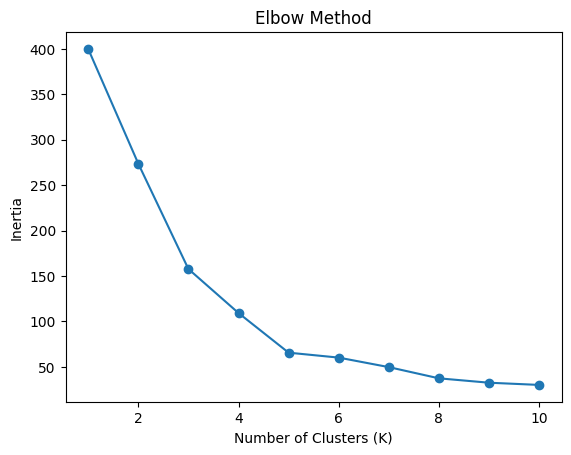

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


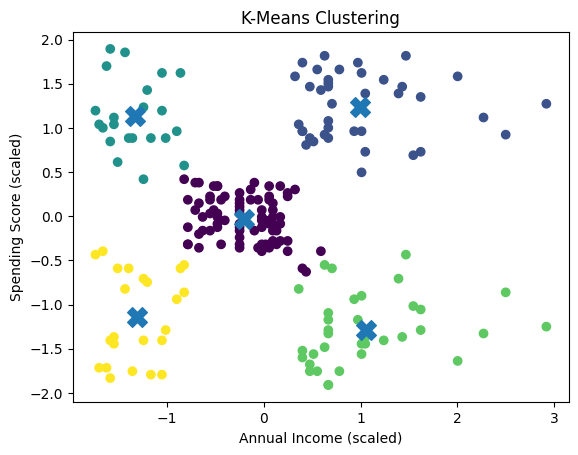

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"/content/Mall_Customers.csv")
print(data.head())

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
print(X.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

data['Cluster'] = labels

print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels))

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=200, marker='X')
plt.title("K-Means Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print(data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
Silhouette Score: 0.5536892843811245
AIC: 963.0010487892964
BIC: 1058.6522524191894


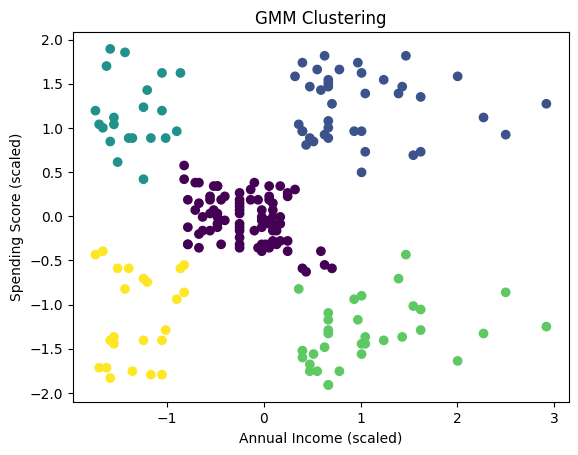

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.642857               49.369048
1                 86.538462               82.128205
2                 25.095238               80.047619
3                 88.818182               16.000000
4                 26.304348               20.913043


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

data = pd.read_csv(r"/content/Mall_Customers.csv")

print(data.head())

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.isnull().sum())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)

data['Cluster'] = labels

print("Silhouette Score:", silhouette_score(X_scaled, labels))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)
plt.title("GMM Clustering")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

print(data.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())
